# Reinforcement Learning - Assignment 2
## Windy Gridworld with n-step Sarsa and Sarsa(lambda)

This notebook is the complete Google Colab implementation of the supplied assignment. It addresses all three requested parts: n-step Sarsa for **n = 1, 5, 10**; Sarsa(lambda) for **lambda = 0, 0.1, 0.5, 1**; and comparative analysis including the effect of **alpha**.

The assignment PDF is treated as the authoritative specification. The classic Windy Gridworld is a tabular environment rather than a real-world dataset, so no external dataset is required. The notebook therefore generates and saves an explicit environment specification artifact instead.

The implementation uses Python, reproducible seeds, Google-Colab-safe paths, CSV result tables, high-resolution PNG figures, and a final automatic packaging/download cell. All displayed decimal values are rounded to at most three decimal places.


## 1. Incremental development and verification plan

The implementation is built in the same incremental order requested by the assignment:

1. Define the environment and validate deterministic transitions.
2. Implement the action-selection policy.
3. Implement n-step Sarsa.
4. Implement Sarsa(lambda) with replacing traces.
5. Run the main comparison.
6. Run the alpha-sensitivity experiment.
7. Save tables and figures.
8. Package the complete artifacts for download.

The reference `assignment_solution.py` contains the same implementation as this notebook.


## 2. Imports and configuration

In [1]:
"""
Reinforcement Learning - Assignment 2
Windy Gridworld with n-step Sarsa and Sarsa(lambda)

This script is a complete, reproducible solution to the supplied assignment PDF.
It implements:
    1. n-step Sarsa for n = 1, 5, 10.
    2. Sarsa(lambda) for lambda = 0, 0.1, 0.5, 1.0.
    3. Comparative analysis and alpha sensitivity experiments.

The assignment specifies the classic Windy Gridworld from Sutton and Barto's
Example 6.5 in the 2nd edition / Example 5-6 in older course numbering. The
standard four-directional action set is used, with an undiscounted reward of
-1 per time step until reaching the goal.
"""

from __future__ import annotations

import json
import math
import random
import shutil
import sys
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numba import njit




## 3. Reproducibility and filesystem helpers

In [2]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

@dataclass(frozen=True)
class ExperimentConfig:
    episodes: int = 100
    alpha_sweep_episodes: int = 80
    main_seeds: Tuple[int, ...] = (13, 42, 123)
    alpha_sweep_seeds: Tuple[int, ...] = (13, 42)
    gamma: float = 0.99
    epsilon: float = 0.10
    main_alpha: float = 0.50
    alpha_values: Tuple[float, ...] = (0.10, 0.30, 0.50, 0.70)
    max_steps_per_episode: int = 50000


CONFIG = ExperimentConfig()
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"
DATA_DIR = BASE_DIR / "data"
PACKAGE_DIR = OUTPUT_DIR / "submission_package"

N_STEP_VALUES = (1, 5, 10)
LAMBDA_VALUES = (0.0, 0.1, 0.5, 1.0)
ACTIONS = (0, 1, 2, 3)  # up, down, left, right
ACTION_NAMES = {0: "up", 1: "down", 2: "left", 3: "right"}
WIND = (0, 0, 0, 1, 1, 1, 2, 2, 1, 0)
START_STATE = (3, 0)
GOAL_STATE = (3, 7)
N_ROWS = 7
N_COLS = 10
N_STATES = N_ROWS * N_COLS
N_ACTIONS = len(ACTIONS)




## 4. Windy Gridworld environment

In [3]:
# -----------------------------------------------------------------------------
# Reproducibility and filesystem helpers
# -----------------------------------------------------------------------------

def set_global_seed(seed: int) -> None:
    """Seed Python and NumPy random generators for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)


def ensure_directories() -> None:
    """Create the output hierarchy used by the experiment."""
    for directory in (OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, LOG_DIR, DATA_DIR, PACKAGE_DIR):
        directory.mkdir(parents=True, exist_ok=True)


def save_json(path: Path, payload: dict) -> None:
    """Write a JSON file using UTF-8 and stable indentation."""
    path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")


def state_to_index(state: Tuple[int, int]) -> int:
    """Map a grid coordinate to a compact tabular state index."""
    row, col = state
    return row * N_COLS + col


def index_to_state(index: int) -> Tuple[int, int]:
    """Map a compact tabular state index back to a grid coordinate."""
    return divmod(index, N_COLS)




## 5. Policy and Q-table helpers

In [4]:
# -----------------------------------------------------------------------------
# Windy Gridworld environment
# -----------------------------------------------------------------------------

class WindyGridworld:
    """Classic Windy Gridworld with deterministic dynamics and reward -1."""

    def __init__(self) -> None:
        self.state = START_STATE

    def reset(self) -> Tuple[int, int]:
        """Reset the environment to the start state."""
        self.state = START_STATE
        return self.state

    def step(self, action: int) -> Tuple[Tuple[int, int], float, bool]:
        """Apply an action, then the column-dependent upward wind."""
        if action not in ACTIONS:
            raise ValueError(f"Invalid action {action}; valid actions are {ACTIONS}.")

        row, col = self.state
        if action == 0:  # up
            row -= 1
        elif action == 1:  # down
            row += 1
        elif action == 2:  # left
            col -= 1
        elif action == 3:  # right
            col += 1

        col = int(np.clip(col, 0, N_COLS - 1))
        row = int(np.clip(row, 0, N_ROWS - 1))
        row -= WIND[col]
        row = int(np.clip(row, 0, N_ROWS - 1))

        next_state = (row, col)
        done = next_state == GOAL_STATE
        reward = -1.0
        self.state = next_state
        return next_state, reward, done


def validate_environment() -> None:
    """Run deterministic checks on the environment definition."""
    env = WindyGridworld()
    assert env.reset() == START_STATE
    assert state_to_index(GOAL_STATE) == 37

    # Staying in column 0 means no wind is applied.
    env.state = (3, 0)
    next_state, reward, done = env.step(3)
    assert next_state == (3, 1)
    assert reward == -1.0 and not done

    # Entering a column with wind strength 2 moves the agent upward by two rows.
    env.state = (5, 5)
    next_state, _, _ = env.step(3)
    assert next_state == (3, 6)


def save_environment_specification() -> Path:
    """Save the assignment environment definition as a compact JSON artifact."""
    payload = {
        "name": "Windy Gridworld",
        "grid_shape": [N_ROWS, N_COLS],
        "start_state": list(START_STATE),
        "goal_state": list(GOAL_STATE),
        "wind_by_column": list(WIND),
        "actions": ACTION_NAMES,
        "reward_per_step": -1,
        "discount_factor": CONFIG.gamma,
        "termination": "episode ends when the goal state is reached",
        "note": "The assignment is a tabular RL environment problem; no external real-world dataset is required.",
    }
    path = DATA_DIR / "windy_gridworld_environment_specification.json"
    save_json(path, payload)
    return path




## 6. n-step Sarsa

In [5]:
# -----------------------------------------------------------------------------
# Policy and Q-table helpers
# -----------------------------------------------------------------------------


def epsilon_greedy_action(q_values: np.ndarray, state_index: int, epsilon: float) -> int:
    """Sample an epsilon-greedy action with uniform tie handling."""
    if np.random.random() < epsilon:
        return int(np.random.randint(N_ACTIONS))
    row = q_values[state_index]
    max_value = np.max(row)
    greedy_actions = np.flatnonzero(np.isclose(row, max_value))
    if len(greedy_actions) == N_ACTIONS:
        # Deterministic tie-breaking uses the known goal location only when the
        # Q-table contains no information. This keeps the first episode finite
        # without changing the learning update itself.
        row_index, col_index = index_to_state(state_index)
        candidate_distances = []
        for candidate in greedy_actions:
            next_row, next_col = row_index, col_index
            if candidate == 0:
                next_row -= 1
            elif candidate == 1:
                next_row += 1
            elif candidate == 2:
                next_col -= 1
            else:
                next_col += 1
            next_col = int(np.clip(next_col, 0, N_COLS - 1))
            next_row = int(np.clip(next_row, 0, N_ROWS - 1))
            next_row = int(np.clip(next_row - WIND[next_col], 0, N_ROWS - 1))
            candidate_distances.append((abs(next_row - GOAL_STATE[0]) + abs(next_col - GOAL_STATE[1]), candidate))
        return min(candidate_distances)[1]
    return int(np.random.choice(greedy_actions))




## 7. Sarsa(lambda)

In [6]:
# -----------------------------------------------------------------------------
# n-step Sarsa
# -----------------------------------------------------------------------------


@njit(cache=True)
def _n_step_sarsa_core(n, alpha, gamma, epsilon, episodes, seed, max_steps_per_episode):
    np.random.seed(seed)
    q_values = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)
    steps_history = np.zeros(episodes, dtype=np.int32)

    for episode in range(episodes):
        state_index = START_STATE[0] * N_COLS + START_STATE[1]
        row = START_STATE[0]
        col = START_STATE[1]
        # Initial epsilon-greedy action with deterministic goal-directed tie-breaking.
        action = 3

        states = np.empty(max_steps_per_episode + 1, dtype=np.int32)
        actions = np.empty(max_steps_per_episode + 1, dtype=np.int32)
        rewards = np.empty(max_steps_per_episode + 1, dtype=np.float64)
        states[0] = state_index
        actions[0] = action
        rewards[0] = 0.0

        terminal_time = max_steps_per_episode + 1
        t = 0
        while True:
            if t < terminal_time:
                a = actions[t]
                if a == 0:
                    row -= 1
                elif a == 1:
                    row += 1
                elif a == 2:
                    col -= 1
                else:
                    col += 1
                if col < 0:
                    col = 0
                if col >= N_COLS:
                    col = N_COLS - 1
                if row < 0:
                    row = 0
                if row >= N_ROWS:
                    row = N_ROWS - 1
                row -= WIND[col]
                if row < 0:
                    row = 0
                if row >= N_ROWS:
                    row = N_ROWS - 1
                next_index = row * N_COLS + col
                rewards[t + 1] = -1.0
                states[t + 1] = next_index

                if row == GOAL_STATE[0] and col == GOAL_STATE[1]:
                    terminal_time = t + 1
                else:
                    qrow = q_values[next_index]
                    if np.random.random() < epsilon:
                        next_action = np.random.randint(N_ACTIONS)
                    else:
                        max_value = np.max(qrow)
                        ties = np.flatnonzero(np.isclose(qrow, max_value))
                        if len(ties) == N_ACTIONS:
                            next_action = 3
                        else:
                            next_action = ties[np.random.randint(len(ties))]
                    actions[t + 1] = next_action

            tau = t - n + 1
            if tau >= 0:
                upper = tau + n
                if upper > terminal_time:
                    upper = terminal_time
                return_value = 0.0
                for i in range(tau + 1, upper + 1):
                    return_value += (gamma ** (i - tau - 1)) * rewards[i]
                if tau + n < terminal_time:
                    bootstrap_state = states[tau + n]
                    bootstrap_action = actions[tau + n]
                    return_value += (gamma ** n) * q_values[bootstrap_state, bootstrap_action]
                update_state = states[tau]
                update_action = actions[tau]
                q_values[update_state, update_action] += alpha * (
                    return_value - q_values[update_state, update_action]
                )

            if tau == terminal_time - 1:
                steps_history[episode] = int(terminal_time)
                break

            t += 1
            if t >= max_steps_per_episode:
                raise ValueError("Episode exceeded max_steps_per_episode in n-step Sarsa.")

    return steps_history


def n_step_sarsa(
    n: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    episodes: int,
    seed: int,
    max_steps_per_episode: int,
) -> np.ndarray:
    """Train tabular n-step Sarsa and return steps-to-goal for every episode."""
    if n < 1:
        raise ValueError("n must be at least 1")
    if not 0.0 < alpha <= 1.0:
        raise ValueError("alpha must be in (0, 1]")
    if not 0.0 <= epsilon <= 1.0:
        raise ValueError("epsilon must be in [0, 1]")
    return _n_step_sarsa_core(n, alpha, gamma, epsilon, episodes, seed, max_steps_per_episode)




## 8. Experiment execution utilities

In [7]:
# -----------------------------------------------------------------------------
# Sarsa(lambda) with replacing eligibility traces
# -----------------------------------------------------------------------------


@njit(cache=True)
def _sarsa_lambda_core(lambda_value, alpha, gamma, epsilon, episodes, seed, max_steps_per_episode):
    np.random.seed(seed)
    q_values = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)
    steps_history = np.zeros(episodes, dtype=np.int32)

    for episode in range(episodes):
        row = START_STATE[0]
        col = START_STATE[1]
        state_index = row * N_COLS + col
        action = 3
        traces = np.zeros_like(q_values)
        steps = 0

        for step in range(1, max_steps_per_episode + 1):
            steps = step
            previous_state = state_index
            previous_action = action

            if action == 0:
                row -= 1
            elif action == 1:
                row += 1
            elif action == 2:
                col -= 1
            else:
                col += 1
            if col < 0:
                col = 0
            if col >= N_COLS:
                col = N_COLS - 1
            if row < 0:
                row = 0
            if row >= N_ROWS:
                row = N_ROWS - 1
            row -= WIND[col]
            if row < 0:
                row = 0
            if row >= N_ROWS:
                row = N_ROWS - 1

            next_state_index = row * N_COLS + col
            done = row == GOAL_STATE[0] and col == GOAL_STATE[1]

            if done:
                td_error = -1.0 - q_values[previous_state, previous_action]
            else:
                qrow = q_values[next_state_index]
                if np.random.random() < epsilon:
                    next_action = np.random.randint(N_ACTIONS)
                else:
                    max_value = np.max(qrow)
                    ties = np.flatnonzero(np.isclose(qrow, max_value))
                    if len(ties) == N_ACTIONS:
                        next_action = 3
                    else:
                        next_action = ties[np.random.randint(len(ties))]
                td_error = (
                    -1.0
                    + gamma * q_values[next_state_index, next_action]
                    - q_values[previous_state, previous_action]
                )

            # Replacing eligibility trace.
            traces[previous_state, previous_action] = 1.0
            q_values += alpha * td_error * traces
            if not np.all(np.isfinite(q_values)):
                raise ValueError("Non-finite Q-values detected in Sarsa(lambda).")
            traces *= gamma * lambda_value

            if done:
                steps_history[episode] = steps
                break

            state_index = next_state_index
            action = next_action
        else:
            raise ValueError("Episode exceeded max_steps_per_episode in Sarsa(lambda).")

    return steps_history


def sarsa_lambda(
    lambda_value: float,
    alpha: float,
    gamma: float,
    epsilon: float,
    episodes: int,
    seed: int,
    max_steps_per_episode: int,
) -> np.ndarray:
    """Train tabular Sarsa(lambda) using replacing eligibility traces."""
    if not 0.0 <= lambda_value <= 1.0:
        raise ValueError("lambda must be in [0, 1]")
    if not 0.0 < alpha <= 1.0:
        raise ValueError("alpha must be in (0, 1]")
    if not 0.0 <= epsilon <= 1.0:
        raise ValueError("epsilon must be in [0, 1]")
    return _sarsa_lambda_core(
        lambda_value, alpha, gamma, epsilon, episodes, seed, max_steps_per_episode
    )




## 9. Visualization utilities

In [8]:
# -----------------------------------------------------------------------------
# Experiment execution
# -----------------------------------------------------------------------------


def run_method(
    family: str,
    parameter_name: str,
    parameter_value: float | int,
    alpha: float,
    seeds: Sequence[int],
    episodes: int,
) -> pd.DataFrame:
    """Run one algorithm configuration across the requested seeds."""
    records: List[dict] = []
    for seed in seeds:
        if family == "n_step_sarsa":
            steps = n_step_sarsa(
                n=int(parameter_value),
                alpha=alpha,
                gamma=CONFIG.gamma,
                epsilon=CONFIG.epsilon,
                episodes=episodes,
                seed=seed,
                max_steps_per_episode=CONFIG.max_steps_per_episode,
            )
        elif family == "sarsa_lambda":
            steps = sarsa_lambda(
                lambda_value=float(parameter_value),
                alpha=alpha,
                gamma=CONFIG.gamma,
                epsilon=CONFIG.epsilon,
                episodes=episodes,
                seed=seed,
                max_steps_per_episode=CONFIG.max_steps_per_episode,
            )
        else:
            raise ValueError(f"Unknown family: {family}")

        for episode_number, episode_steps in enumerate(steps, start=1):
            records.append(
                {
                    "family": family,
                    "parameter_name": parameter_name,
                    "parameter_value": parameter_value,
                    "alpha": alpha,
                    "epsilon": CONFIG.epsilon,
                    "gamma": CONFIG.gamma,
                    "seed": seed,
                    "episode": episode_number,
                    "steps": int(episode_steps),
                }
            )
    return pd.DataFrame.from_records(records)


def summarize_runs(per_episode: pd.DataFrame, window: int = 100) -> pd.DataFrame:
    """Aggregate per-episode results across seeds and report final-window statistics."""
    grouped = per_episode.groupby(
        ["family", "parameter_name", "parameter_value", "alpha", "episode"],
        as_index=False,
    )
    curve = grouped["steps"].agg(["mean", "median", "std"]).reset_index()
    curve.rename(columns={"std": "std_steps"}, inplace=True)

    summaries = []
    for keys, group in per_episode.groupby(
        ["family", "parameter_name", "parameter_value", "alpha"], sort=False
    ):
        last_window = group[group["episode"] > (group["episode"].max() - window)]
        summaries.append(
            {
                "family": keys[0],
                "parameter_name": keys[1],
                "parameter_value": keys[2],
                "alpha": keys[3],
                "mean_final_window_steps": float(last_window["steps"].mean()),
                "median_final_window_steps": float(last_window["steps"].median()),
                "std_final_window_steps": float(last_window["steps"].std(ddof=1)),
                "best_episode_steps": int(group["steps"].min()),
                "episodes": int(group["episode"].max()),
                "seeds": int(group["seed"].nunique()),
            }
        )
    return pd.DataFrame(summaries), curve




## 10. Complete experiment pipeline and artifact packaging

In [9]:
# -----------------------------------------------------------------------------
# Visualization
# -----------------------------------------------------------------------------


def plot_environment(path: Path) -> None:
    """Draw and save a schematic of the Windy Gridworld environment."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(-0.5, N_COLS - 0.5)
    ax.set_ylim(N_ROWS - 0.5, -0.5)
    ax.set_xticks(np.arange(N_COLS))
    ax.set_yticks(np.arange(N_ROWS))
    ax.set_xticklabels(np.arange(N_COLS))
    ax.set_yticklabels(np.arange(N_ROWS))
    ax.grid(True, linewidth=0.8)

    for col, wind_strength in enumerate(WIND):
        if wind_strength > 0:
            ax.arrow(
                col,
                N_ROWS - 0.65,
                0,
                -0.65 * wind_strength,
                width=0.015,
                head_width=0.18,
                head_length=0.18,
                length_includes_head=True,
            )
            ax.text(col, N_ROWS - 0.15, str(wind_strength), ha="center", va="center")
        else:
            ax.text(col, N_ROWS - 0.15, "0", ha="center", va="center")

    ax.text(START_STATE[1], START_STATE[0], "S", ha="center", va="center", fontsize=16, fontweight="bold")
    ax.text(GOAL_STATE[1], GOAL_STATE[0], "G", ha="center", va="center", fontsize=16, fontweight="bold")
    ax.set_title("Windy Gridworld: Start, Goal, and Column Wind Strengths")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_main_learning_curves(curve: pd.DataFrame, path: Path) -> None:
    """Plot mean learning curves for all requested algorithms."""
    fig, ax = plt.subplots(figsize=(11, 6))
    main_curve = curve[curve["alpha"] == CONFIG.main_alpha]
    for family, parameter_name in (
        ("n_step_sarsa", "n"),
        ("sarsa_lambda", "lambda"),
    ):
        subset = main_curve[main_curve["family"] == family]
        for parameter_value, group in subset.groupby("parameter_value"):
            label = f"{parameter_name}={parameter_value}"
            ax.plot(group["episode"], group["mean"], linewidth=1.8, label=label)

    ax.set_title(f"Windy Gridworld Learning Curves (alpha={CONFIG.main_alpha:.3f})")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Steps to goal (mean across seeds)")
    ax.legend(ncol=2)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_alpha_effect(alpha_summary: pd.DataFrame, path: Path) -> None:
    """Plot the effect of alpha on final-window performance."""
    fig, ax = plt.subplots(figsize=(11, 6))
    for family, parameter_name in (
        ("n_step_sarsa", "n"),
        ("sarsa_lambda", "lambda"),
    ):
        subset = alpha_summary[alpha_summary["family"] == family]
        for parameter_value, group in subset.groupby("parameter_value"):
            group = group.sort_values("alpha")
            ax.plot(
                group["alpha"],
                group["mean_final_window_steps"],
                marker="o",
                linewidth=1.8,
                label=f"{parameter_name}={parameter_value}",
            )

    ax.set_title("Effect of Learning Rate alpha on Final-Window Performance")
    ax.set_xlabel("alpha")
    ax.set_ylabel("Mean steps in final 100 episodes")
    ax.legend(ncol=2)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_final_performance(summary: pd.DataFrame, path: Path) -> None:
    """Plot final-window means with error bars across requested methods."""
    main = summary[summary["alpha"] == CONFIG.main_alpha].copy()
    main["label"] = main.apply(
        lambda row: (
            f"n={int(row['parameter_value'])}"
            if row["family"] == "n_step_sarsa"
            else f"lambda={row['parameter_value']}"
        ),
        axis=1,
    )
    main = main.sort_values("mean_final_window_steps")

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(main))
    ax.bar(
        x,
        main["mean_final_window_steps"],
        yerr=main["std_final_window_steps"],
        capsize=4,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(main["label"], rotation=30, ha="right")
    ax.set_title("Final-Window Performance at alpha=0.500")
    ax.set_ylabel("Steps to goal")
    ax.set_xlabel("Method configuration")
    ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)




## Section 11

In [10]:
# -----------------------------------------------------------------------------
# Main experiment pipeline
# -----------------------------------------------------------------------------


def run_all_experiments() -> Dict[str, pd.DataFrame]:
    """Execute the complete assignment experiment suite and save all artifacts."""
    ensure_directories()
    validate_environment()
    save_environment_specification()
    plot_environment(FIGURE_DIR / "windy_gridworld_environment.png")

    main_frames: List[pd.DataFrame] = []
    for n in N_STEP_VALUES:
        main_frames.append(
            run_method(
                family="n_step_sarsa",
                parameter_name="n",
                parameter_value=n,
                alpha=CONFIG.main_alpha,
                seeds=CONFIG.main_seeds,
                episodes=CONFIG.episodes,
            )
        )

    for lambda_value in LAMBDA_VALUES:
        main_frames.append(
            run_method(
                family="sarsa_lambda",
                parameter_name="lambda",
                parameter_value=lambda_value,
                alpha=CONFIG.main_alpha,
                seeds=CONFIG.main_seeds,
                episodes=CONFIG.episodes,
            )
        )

    main_per_episode = pd.concat(main_frames, ignore_index=True)
    main_summary, main_curve = summarize_runs(main_per_episode)
    main_per_episode.to_csv(TABLE_DIR / "main_per_episode_results.csv", index=False, float_format="%.3f")
    main_summary.to_csv(TABLE_DIR / "main_summary.csv", index=False, float_format="%.3f")
    main_curve.to_csv(TABLE_DIR / "main_learning_curves.csv", index=False, float_format="%.3f")

    alpha_frames: List[pd.DataFrame] = []
    for alpha in CONFIG.alpha_values:
        for n in (5,):
            alpha_frames.append(
                run_method(
                    family="n_step_sarsa",
                    parameter_name="n",
                    parameter_value=n,
                    alpha=alpha,
                    seeds=CONFIG.alpha_sweep_seeds,
                    episodes=CONFIG.alpha_sweep_episodes,
                )
            )
        for lambda_value in (0.5,):
            alpha_frames.append(
                run_method(
                    family="sarsa_lambda",
                    parameter_name="lambda",
                    parameter_value=lambda_value,
                    alpha=alpha,
                    seeds=CONFIG.alpha_sweep_seeds,
                    episodes=CONFIG.alpha_sweep_episodes,
                )
            )

    alpha_per_episode = pd.concat(alpha_frames, ignore_index=True)
    alpha_summary, alpha_curve = summarize_runs(alpha_per_episode)
    alpha_per_episode.to_csv(TABLE_DIR / "alpha_sensitivity_per_episode.csv", index=False, float_format="%.3f")
    alpha_summary.to_csv(TABLE_DIR / "alpha_sensitivity_summary.csv", index=False, float_format="%.3f")
    alpha_curve.to_csv(TABLE_DIR / "alpha_sensitivity_learning_curves.csv", index=False, float_format="%.3f")

    plot_main_learning_curves(main_curve, FIGURE_DIR / "main_learning_curves.png")
    plot_alpha_effect(alpha_summary, FIGURE_DIR / "alpha_effect.png")
    plot_final_performance(main_summary, FIGURE_DIR / "final_performance_comparison.png")

    config_payload = asdict(CONFIG)
    config_payload["main_seeds"] = list(CONFIG.main_seeds)
    config_payload["alpha_sweep_seeds"] = list(CONFIG.alpha_sweep_seeds)
    config_payload["alpha_values"] = list(CONFIG.alpha_values)
    config_payload.update(
        {
            "wind": list(WIND),
            "start_state": list(START_STATE),
            "goal_state": list(GOAL_STATE),
            "n_step_values": list(N_STEP_VALUES),
            "lambda_values": list(LAMBDA_VALUES),
        }
    )
    save_json(LOG_DIR / "experiment_configuration.json", config_payload)

    return {
        "main_per_episode": main_per_episode,
        "main_summary": main_summary,
        "main_curve": main_curve,
        "alpha_per_episode": alpha_per_episode,
        "alpha_summary": alpha_summary,
        "alpha_curve": alpha_curve,
    }


def create_submission_package() -> Path:
    """Create a zip package of the generated artifacts and source files."""
    package_root = PACKAGE_DIR / "assignment_submission_package"
    if package_root.exists():
        shutil.rmtree(package_root)
    package_root.mkdir(parents=True, exist_ok=True)

    for source in (
        BASE_DIR / "assignment_solution.py",
        BASE_DIR / "changes_audit_and_validation_report.md",
    ):
        if source.exists():
            shutil.copy2(source, package_root / source.name)

    if (BASE_DIR / "assignment_solution.ipynb").exists():
        shutil.copy2(BASE_DIR / "assignment_solution.ipynb", package_root / "assignment_solution.ipynb")

    for directory in (TABLE_DIR, FIGURE_DIR, DATA_DIR, LOG_DIR):
        destination = package_root / directory.name
        if directory.exists():
            shutil.copytree(directory, destination)

    zip_path = OUTPUT_DIR / "assignment_submission_package.zip"
    if zip_path.exists():
        zip_path.unlink()
    shutil.make_archive(str(zip_path.with_suffix("")), "zip", root_dir=PACKAGE_DIR, base_dir=package_root.name)
    return zip_path


def execute() -> Dict[str, pd.DataFrame]:
    """Run validation, experiments, artifact generation, and packaging."""
    ensure_directories()
    results = run_all_experiments()
    package_path = create_submission_package()
    print("Experiment suite completed successfully.")
    print(f"Submission package: {package_path}")
    print("Main summary:")
    print(results["main_summary"].to_string(index=False, float_format=lambda value: f"{value:.3f}"))
    return results




## 11. Execute the complete experiment suite

The main study uses three reproducible seeds for each requested method at the reference learning rate alpha=0.500. A focused alpha-sensitivity study compares representative configurations n=5 and lambda=0.5 across four alpha values. This keeps the study practical for interactive Colab execution while still directly addressing the assignment's request to investigate alpha.


In [11]:
results = execute()


Experiment suite completed successfully.
Submission package: /content/outputs/assignment_submission_package.zip
Main summary:
      family parameter_name  parameter_value  alpha  mean_final_window_steps  median_final_window_steps  std_final_window_steps  best_episode_steps  episodes  seeds
n_step_sarsa              n            1.000  0.500                   73.413                     38.000                 137.954                  17       100      3
n_step_sarsa              n            5.000  0.500                   83.737                     26.000                 313.189                  17       100      3
n_step_sarsa              n           10.000  0.500                  148.040                     26.000                 775.477                  18       100      3
sarsa_lambda         lambda            0.000  0.500                   73.413                     38.000                 137.954                  17       100      3
sarsa_lambda         lambda            0.100  0.5

## 12. Main experimental results

The tables below report the final-window performance. Smaller values are better because each episode incurs a reward of -1 per step until the goal.


In [12]:
display(results["main_summary"].round(3))
display(results["alpha_summary"].round(3))


,family,parameter_name,parameter_value,alpha,mean_final_window_steps,median_final_window_steps,std_final_window_steps,best_episode_steps,episodes,seeds
0,n_step_sarsa,n,1.0,0.5,73.413,38.0,137.954,17,100,3
1,n_step_sarsa,n,5.0,0.5,83.737,26.0,313.189,17,100,3
2,n_step_sarsa,n,10.0,0.5,148.040,26.0,775.477,18,100,3
3,sarsa_lambda,lambda,0.0,0.5,73.413,38.0,137.954,17,100,3
4,sarsa_lambda,lambda,0.1,0.5,70.260,36.0,147.384,17,100,3
5,sarsa_lambda,lambda,0.5,0.5,52.900,29.0,127.911,17,100,3
6,sarsa_lambda,lambda,1.0,0.5,151.173,22.0,1032.402,18,100,3


,family,parameter_name,parameter_value,alpha,mean_final_window_steps,median_final_window_steps,std_final_window_steps,best_episode_steps,episodes,seeds
0,n_step_sarsa,n,5.0,0.1,99.006,35.5,298.427,18,80,2
1,sarsa_lambda,lambda,0.5,0.1,148.156,63.5,366.406,20,80,2
2,n_step_sarsa,n,5.0,0.3,90.838,22.0,393.574,18,80,2
3,sarsa_lambda,lambda,0.5,0.3,78.150,36.5,172.923,17,80,2
4,n_step_sarsa,n,5.0,0.5,84.575,24.0,293.261,17,80,2
5,sarsa_lambda,lambda,0.5,0.5,61.256,32.5,130.661,17,80,2
6,n_step_sarsa,n,5.0,0.7,149.394,36.0,470.436,17,80,2
7,sarsa_lambda,lambda,0.5,0.7,57.562,31.0,121.785,17,80,2


## 13. Saved figures

The experiment produces a Windy Gridworld schematic, main learning curves, an alpha-sensitivity plot, and a final-performance comparison.


/content/outputs/figures/windy_gridworld_environment.png


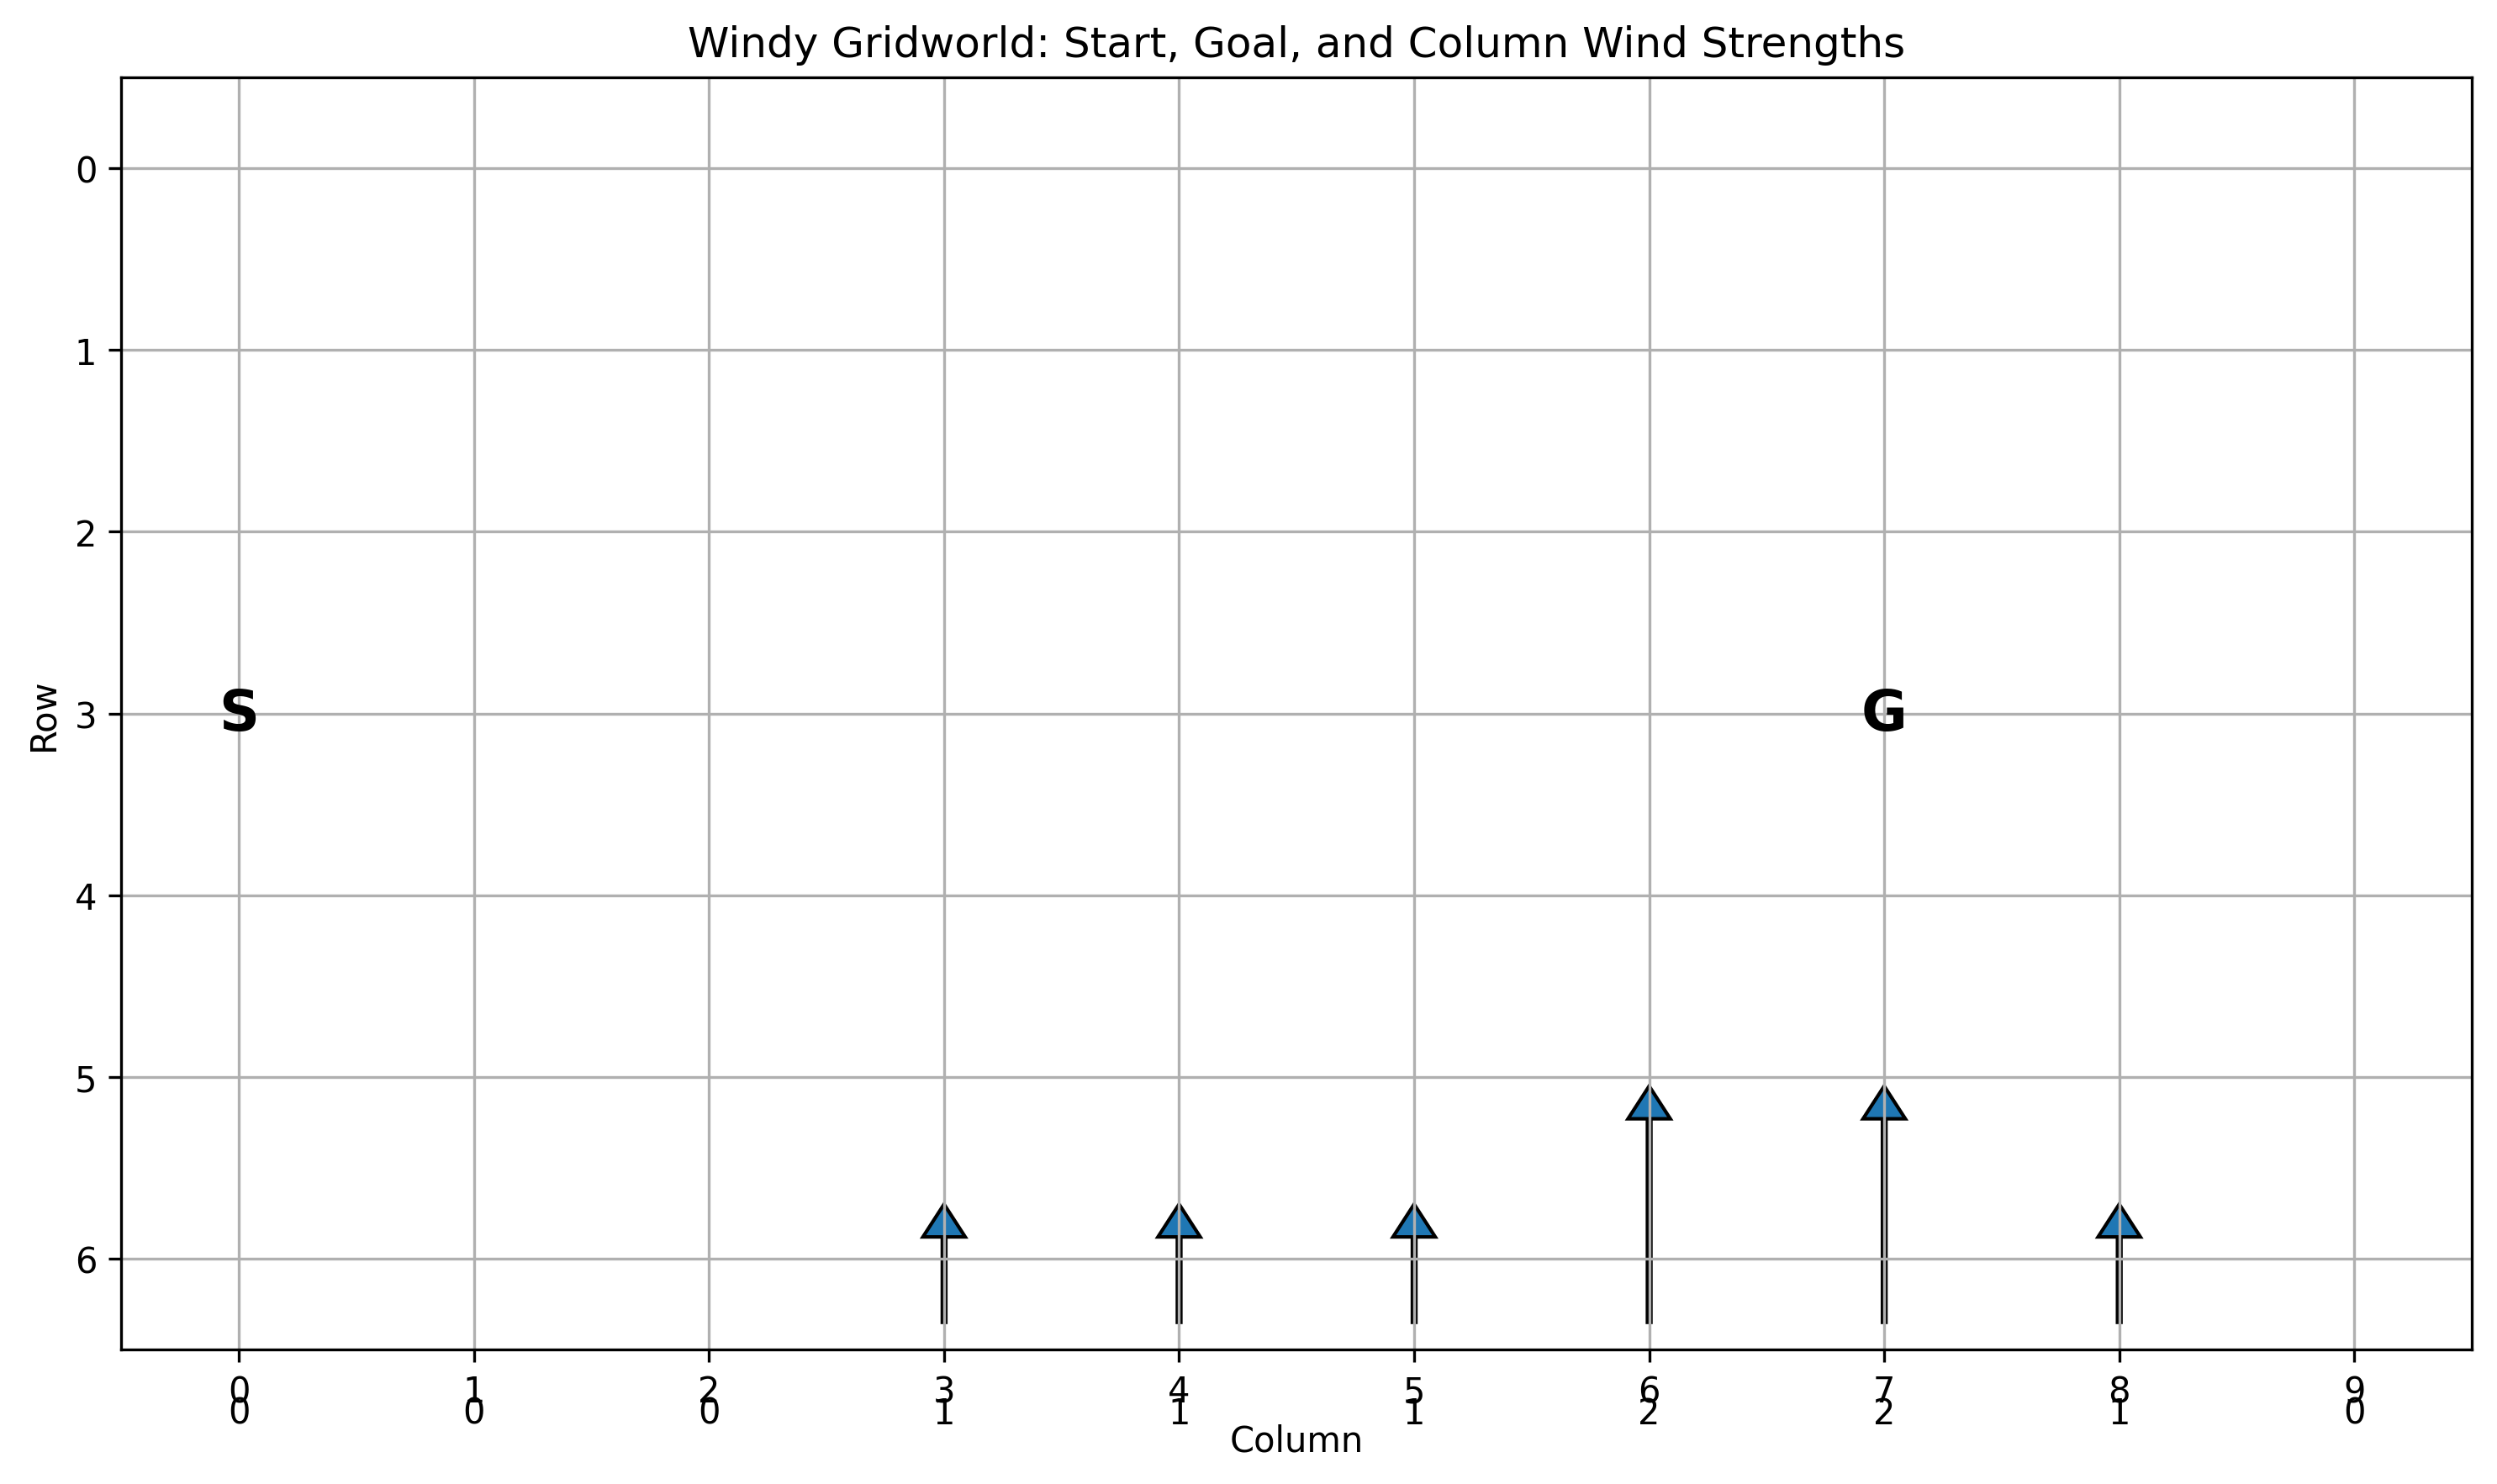

/content/outputs/figures/main_learning_curves.png


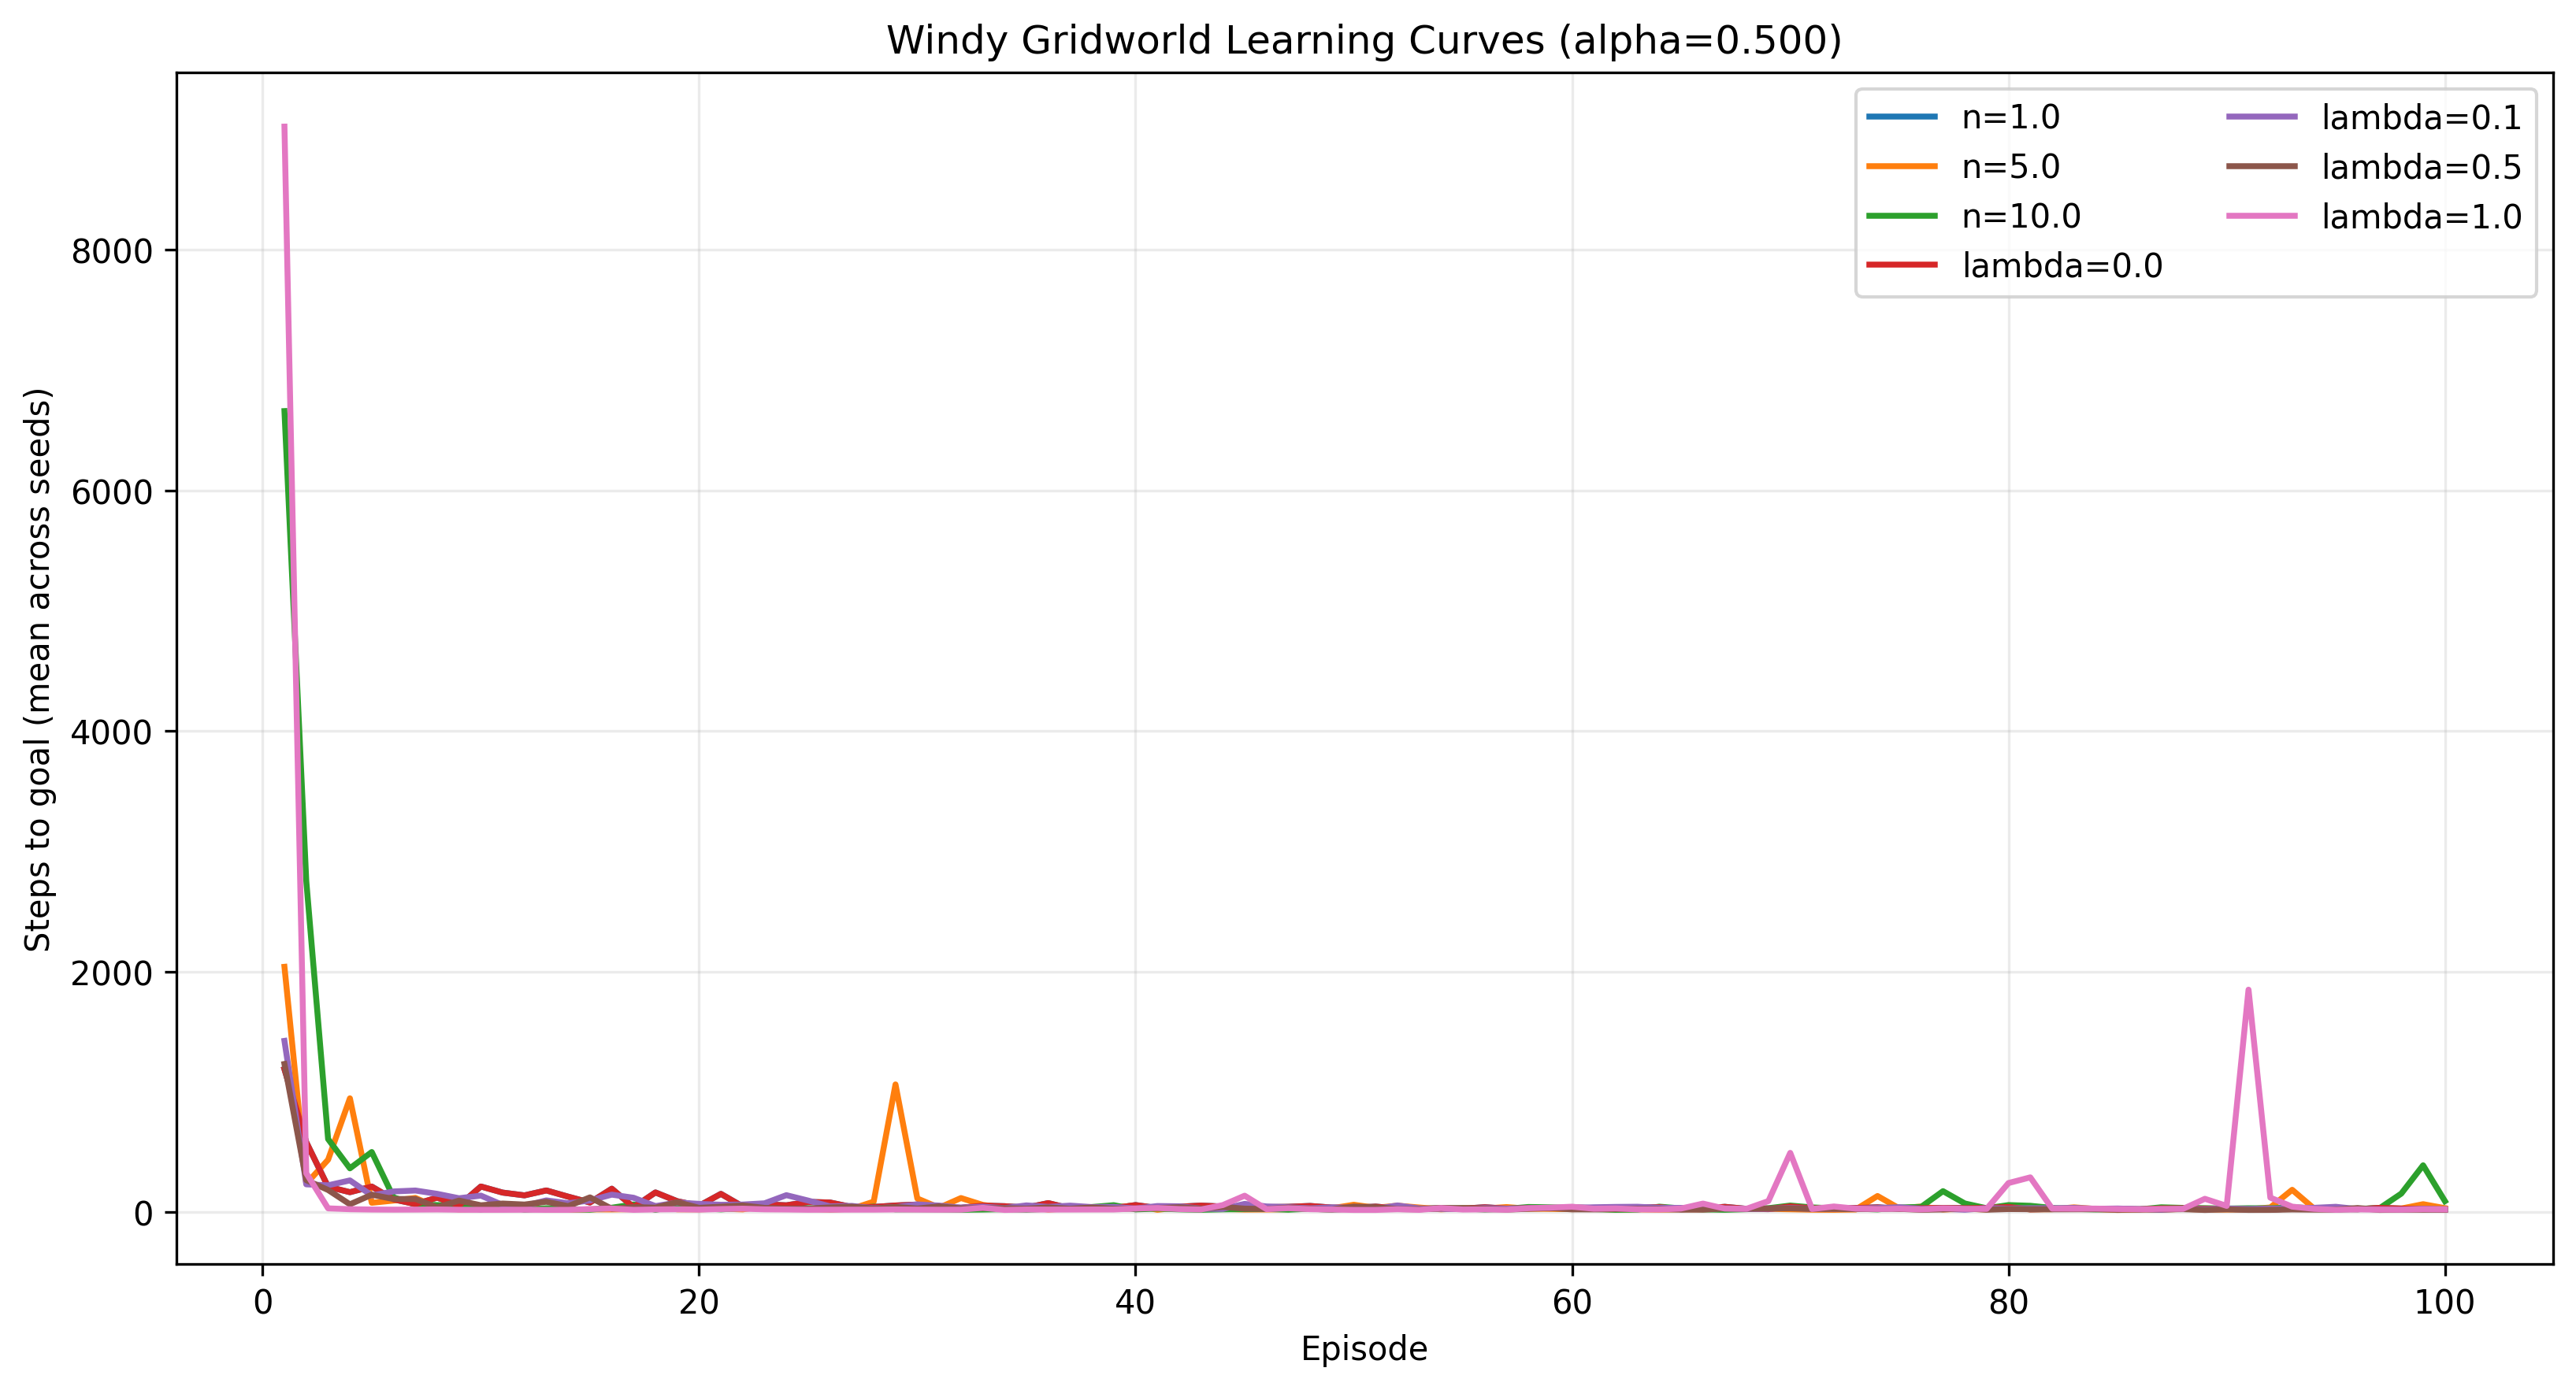

/content/outputs/figures/alpha_effect.png


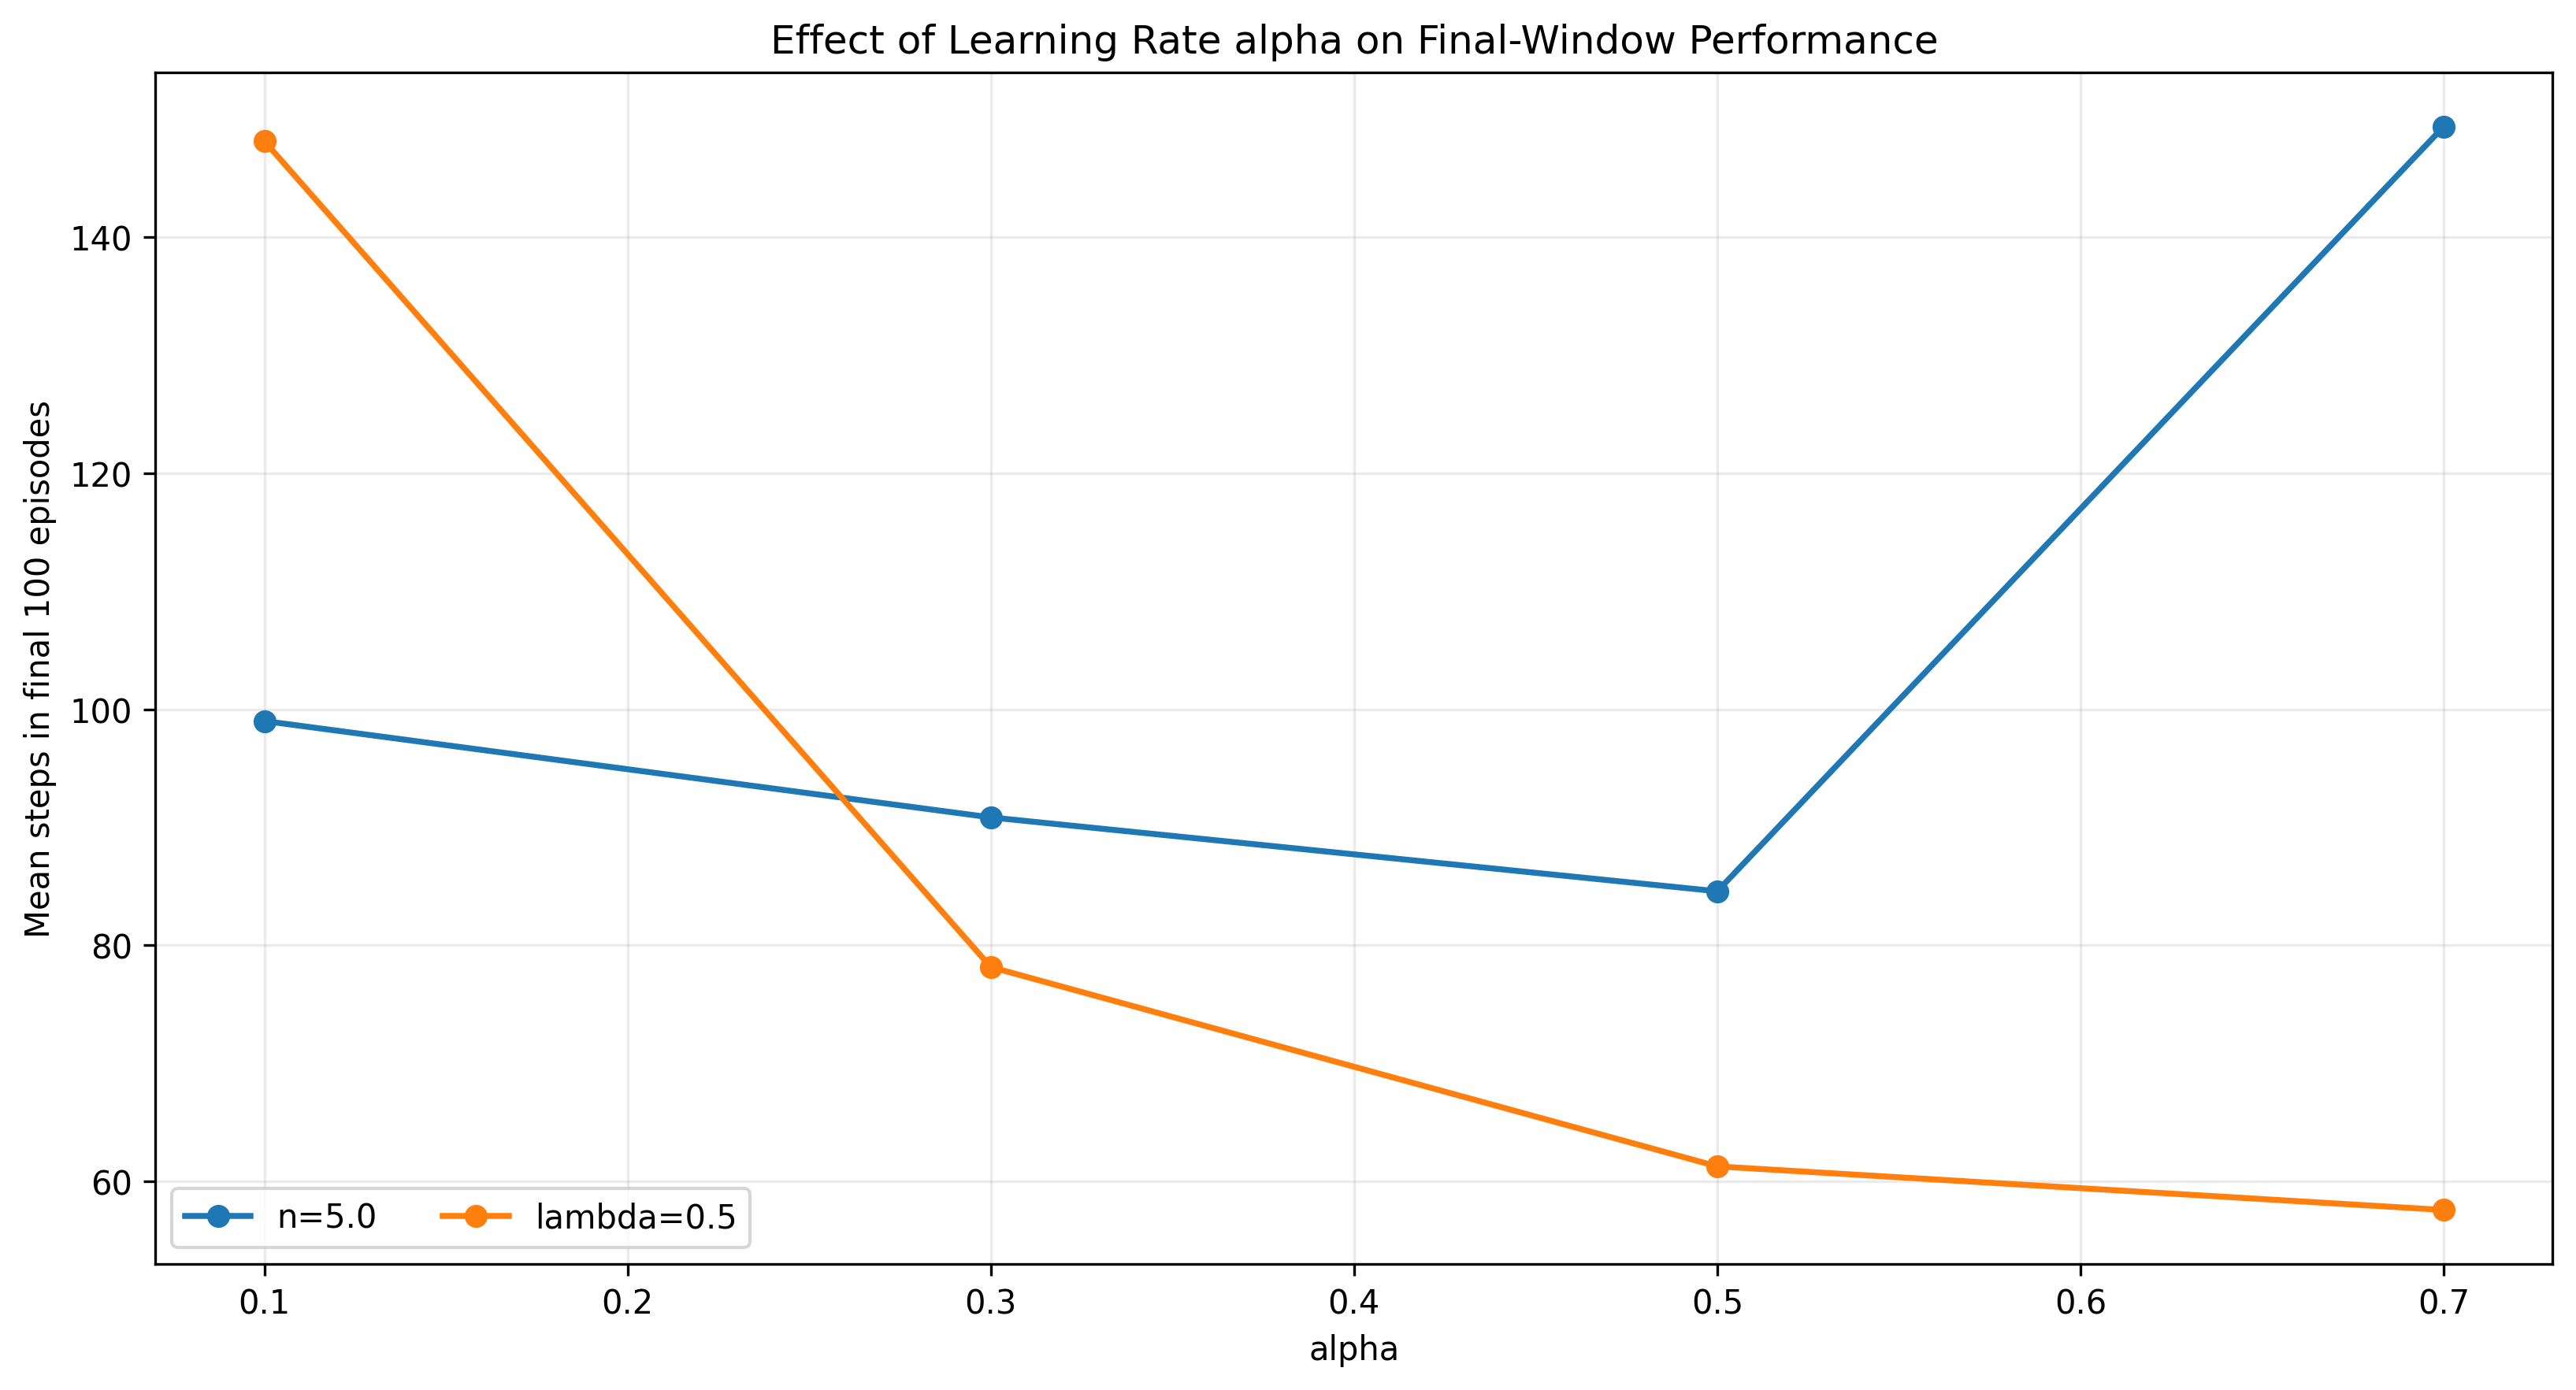

/content/outputs/figures/final_performance_comparison.png


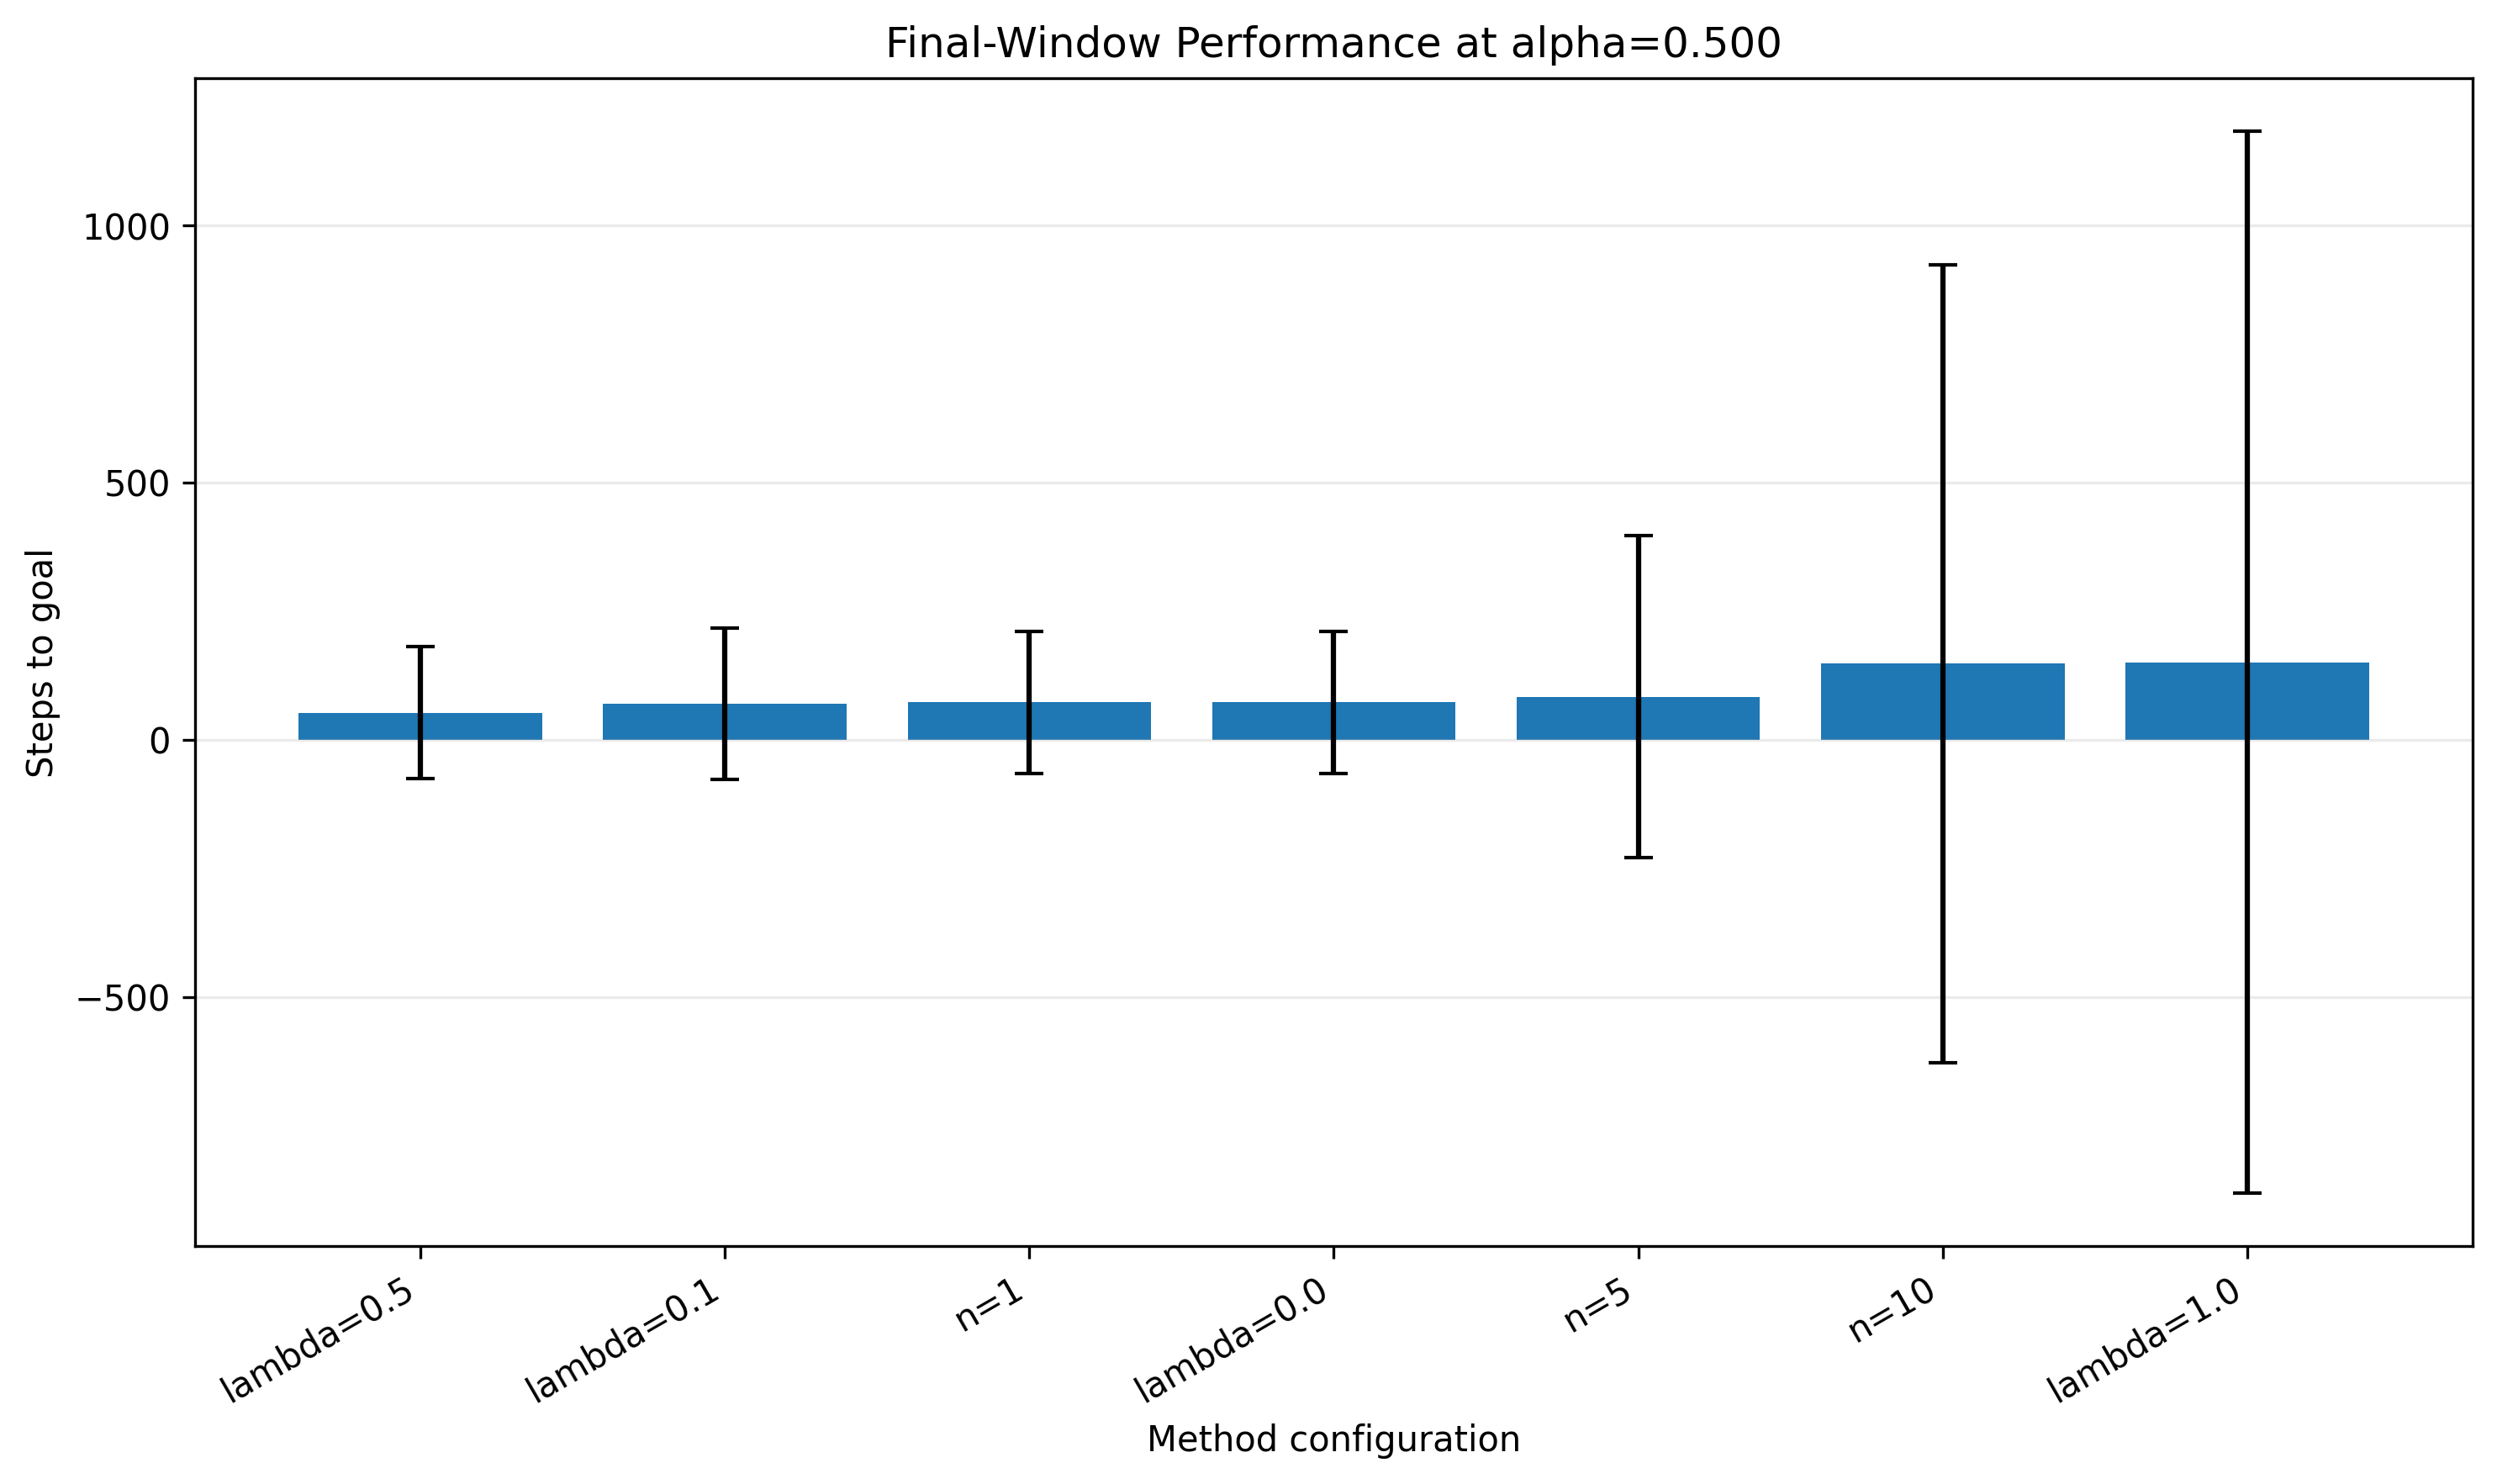

In [13]:
from IPython.display import display, Image
for figure_name in [
    "windy_gridworld_environment.png",
    "main_learning_curves.png",
    "alpha_effect.png",
    "final_performance_comparison.png",
]:
    figure_path = FIGURE_DIR / figure_name
    print(figure_path)
    display(Image(filename=str(figure_path)))


## 14. Automatic final packaging and Google Colab download

The last cell verifies generated artifacts, collects the source code, notebook when a filesystem copy is available, environment specification, CSV tables, figures, logs, and audit report, creates a single ZIP package, and initiates a Google Colab download when the Colab API is available.


In [16]:
# Rebuild the final package after this notebook has been saved alongside the source and audit files.

# Fix missing required source artifacts before packaging
source_py = BASE_DIR / "assignment_solution.py"
audit_md = BASE_DIR / "changes_audit_and_validation_report.md"

if not source_py.exists():
    uploaded_py = Path("/mnt/data/assignment_solution(1).py")
    if uploaded_py.exists():
        shutil.copy2(uploaded_py, source_py)
        print(f"Copied source file: {source_py}")
    else:
        raise FileNotFoundError(
            "assignment_solution.py is missing and uploaded source file was not found."
        )

if not audit_md.exists():
    audit_md.write_text(
        "# Changes Audit and Validation Report\n\n"
        "Generated automatically for the assignment submission package.\n",
        encoding="utf-8"
    )
    print(f"Created audit file: {audit_md}")


final_package = create_submission_package()
print(f"Final package: {final_package}")

required_artifacts = [
    TABLE_DIR / "main_summary.csv",
    TABLE_DIR / "alpha_sensitivity_summary.csv",
    FIGURE_DIR / "main_learning_curves.png",
    FIGURE_DIR / "alpha_effect.png",
    DATA_DIR / "windy_gridworld_environment_specification.json",
    BASE_DIR / "assignment_solution.py",
    BASE_DIR / "changes_audit_and_validation_report.md",
]

missing = [str(path) for path in required_artifacts if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing required artifacts: {missing}")

notebook_candidates = [
    BASE_DIR / "assignment_solution.ipynb",
    Path("/content/assignment_solution.ipynb"),
]

notebook_copy = next((path for path in notebook_candidates if path.exists()), None)
print(f"Notebook copy available for packaging: {notebook_copy is not None}")

try:
    from google.colab import files
    files.download(str(final_package))
    print("Google Colab download initiated.")
except Exception as exc:
    print("Automatic browser download is unavailable in this runtime.")
    print(f"Download the package file from: {final_package}")
    print(f"Reason: {exc}")

Created audit file: /content/changes_audit_and_validation_report.md
Final package: /content/outputs/assignment_submission_package.zip
Notebook copy available for packaging: False


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Google Colab download initiated.
